In [3]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

from PIL import Image
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import time
from tqdm import tqdm

import os
import shutil
import random
from pathlib import Path

# Skin Diseases Classifier
* Kaggle: https://www.kaggle.com/datasets/sponishflea/classification-of-skin-diseases?resource=download

In [4]:
root_dir = "./data/skin_diseases"
train_dir = os.path.join(root_dir, "train")
test_dir = os.path.join(root_dir, "test")

In [5]:
# class 폴더명 -> 정수 라벨 매핑
class_names = sorted([d.name for d in Path(train_dir).iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(class_names)}

# 전부 .jpg 인지 확인 - .jpg 아닌 것들 출력
def check_exts(pathdir):
    unique_ext = {p.suffix.lower() for p in Path(pathdir).rglob("*") if p.is_file()}
    print(unique_ext)

check_exts(train_dir)

{'.jpg'}


In [6]:
class ourDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        # 각 이미지가 들어있는 디렉토리를 리스트에 추가.
        img_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
        self.base_dir = base_dir
        self.img_paths = []
        self.labels = []

        # 정렬해서 클래스 인덱스가 OS/실행마다 바뀌지 않게
        img_dirs = sorted(img_dirs)
        
        # 각 클래스와 인덱스가 맵핑된 딕셔너리 생성.
        self.cls_to_idx = {cls: i for i, cls in enumerate(img_dirs)}
        self.idx_to_cls = {i: cls for cls, i in self.cls_to_idx.items()}
        
        exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

        # 이미지 경로와 레이블을 리스트에 추가.
        for img_dir in img_dirs:
            dir_path = os.path.join(base_dir, img_dir)
            img_names = [
                os.path.join(dir_path, f)
                for f in os.listdir(dir_path)
                if f.lower().endswith(exts)   # ✅ 대소문자/확장자 커버
            ]
            self.img_paths.extend(img_names)
            self.labels.extend([self.cls_to_idx[img_dir]] * len(img_names))

        self.transform = transform


    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        # Image Augmentation 수행 ( 수행을 하지 않고 데이터로더로 데이터셋 확인시 배치사이즈는 1로 해야 한다. )
        if self.transform:
            image = self.transform(image)

        return image, label


    def __len__(self):
        return len(self.img_paths)


In [7]:
# 데이터 분포 확인
def print_cls_dist(ds):
    if isinstance(ds, Subset):
        # Subset 객체에서 오리지널 dataset를 접근할 수 있다.
        # Subset 객체의 indices를 이용해 labels를 추출한다.
        base = ds.dataset
        labels = np.array([base.labels[i] for i in ds.indices])
        idx_to_cls = base.idx_to_cls
    else:
        labels = np.array(ds.labels)
        idx_to_cls = ds.idx_to_cls

    # 클래스명과 이미지 개수 출력 ( np로 순서에 대한 정보를 유지할 수 있음 )
    unique, counts = np.unique(labels, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"{int(cls)}.{idx_to_cls[int(cls)]:18}: {int(count)}")

In [8]:
# 인스턴스
base_dataset = ourDataset(base_dir=train_dir)
dataloader = DataLoader(base_dataset, batch_size = 1, shuffle=True)

# 데이터셋의 크기 확인
print('Size of Dataset:', len(base_dataset))
print('Size of Dataloader:', len(dataloader))

# 클래스 개수
num_classes = len(base_dataset.cls_to_idx)
print('Number of Classes:', num_classes)

# 클래스별 데이터 분포
print_cls_dist(base_dataset)

Size of Dataset: 1494
Size of Dataloader: 1494
Number of Classes: 5
0.acne              : 300
1.eksim             : 297
2.herpes            : 300
3.panu              : 297
4.rosacea           : 300


In [9]:
def get_base_and_indices(ds):
    indices = None
    
    while isinstance(ds, Subset):
        if indices is None:
            indices = list(ds.indices)
        else:
            indices = [ds.indices[i] for i in indices]
        ds = ds.dataset

    base = ds
    
    if indices is None:
        indices = list(range(len(base)))

    return base, indices

In [10]:
#  imbalanced 데이터셋 해결책 3가지:
# 1. Oversampling
# 2. Undersampling
# 3. Class Weighting


## Undersampling

def undersample_indices_from_labels(indices, labels, seed=42, per_class=None):
    rng = np.random.default_rng(seed)
    indices = np.asarray(indices)
    labels = np.asarray(labels)

    cls_to_idx = {}
    for idx, y in zip(indices, labels):
        cls_to_idx.setdefault(int(y), []).append(int(idx))

    counts = {c: len(v) for c, v in cls_to_idx.items()}
    if per_class is None:
        per_class = min(counts.values())

    kept = []
    for c, idxs in cls_to_idx.items():
        idxs = np.array(idxs)
        if len(idxs) <= per_class:
            kept.append(idxs)
        else:
            kept.append(rng.choice(idxs, size=per_class, replace=False))

    kept = np.concatenate(kept)
    rng.shuffle(kept)
    return kept

# 인스턴스
base_dataset = ourDataset(base_dir=train_dir)

all_idx = np.arange(len(base_dataset))
all_labels = np.array(base_dataset.labels)

undersampled_indices  = undersample_indices_from_labels(all_idx, all_labels)

undersampled_dataset = Subset(base_dataset, undersampled_indices)

# 클래스별 데이터 분포
print_cls_dist(undersampled_dataset)

# dataset 형태
print(type(undersampled_dataset))

0.acne              : 297
1.eksim             : 297
2.herpes            : 297
3.panu              : 297
4.rosacea           : 297
<class 'torch.utils.data.dataset.Subset'>


In [11]:
class WithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]   # base_dataset이 transform=None이면 여기서 x는 PIL
        x = self.transform(x)
        return x, y

{0: 'acne', 1: 'eksim', 2: 'herpes', 3: 'panu', 4: 'rosacea'}


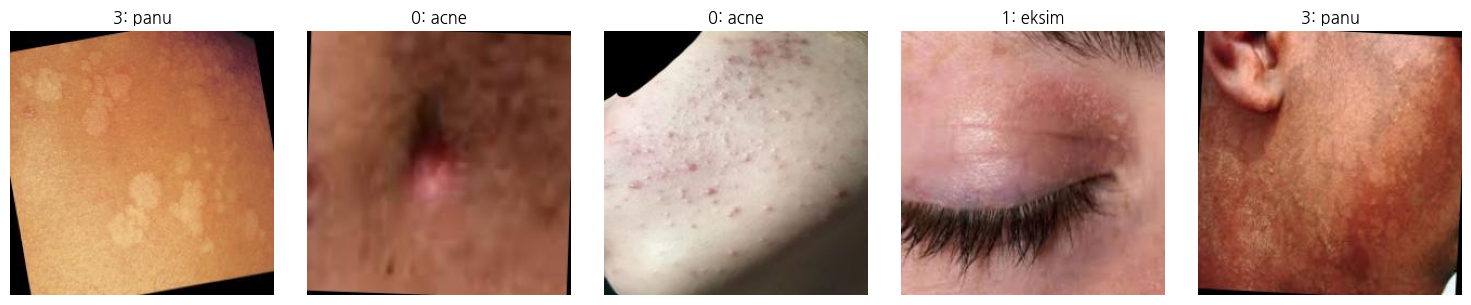

In [12]:
# 데이터 시각화
def _get_base_and_local_index(dataset, idx):
    """
    Subset이면 base dataset + 원본 인덱스로 변환해서 접근.
    Subset-of-Subset은 안 쓰는 전제지만, 혹시 몰라 while로 안전하게 처리.
    """
    base = dataset
    base_idx = idx
    while isinstance(base, Subset):
        base_idx = int(base.indices[base_idx])
        base = base.dataset
    return base, base_idx

def _to_display_img(x):
    """
    x가 PIL이면 그대로, Tensor면 HWC로 변환해서 numpy로.
    """
    if hasattr(x, "permute"):  # torch Tensor
        x = x.detach().cpu()
        x = x.permute(1, 2, 0).numpy()
        x = np.clip(x, 0, 1)
    return x

def show_images(dataset, num_images=5, seed=None):
    if seed is not None:
        random.seed(seed)

    # idx_to_cls 찾기 (Subset이면 base_dataset에서)
    base0, _ = _get_base_and_local_index(dataset, 0)
    idx_to_cls = getattr(base0, "idx_to_cls", None)

    # 랜덤 샘플 idx 뽑기
    picks = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    plt.figure(figsize=(num_images * 3, 3))
    for i, ds_i in enumerate(picks):
        base, base_i = _get_base_and_local_index(dataset, ds_i)

        # base에서 raw PIL 얻기 위해 transform 잠깐 꺼두기 (ourDataset 기준)
        old_tf = getattr(base, "transform", None)
        if hasattr(base, "transform"):
            base.transform = None
        img, label = base[base_i]
        if hasattr(base, "transform"):
            base.transform = old_tf

        plt.subplot(1, num_images, i + 1)
        title = f"{label}"
        if idx_to_cls is not None:
            title = f"{label}: {idx_to_cls[int(label)]}"
        plt.title(title)

        plt.imshow(_to_display_img(img))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# undersampling된 데이터셋은 Subset이기 때문에 idx_to_cls attribute을 강제로 붙임
base = undersampled_dataset.dataset if isinstance(undersampled_dataset, Subset) else undersampled_dataset
print(base.idx_to_cls)

show_images(base)

In [13]:
# 입력데이터셋의 정보 확인

def check_hw_sizes(dataset, batch_size=1):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda x: x  # PIL 대응용
    )

    hw_sizes = []

    for batch in loader:
        for image, _ in batch:
            # Tensor인 경우 (C, H, W)
            if hasattr(image, "shape") and len(image.shape) == 3:
                if image.shape[0] in [1, 3]:   # CHW
                    h, w = image.shape[1], image.shape[2]
                else:  # 혹시 HWC
                    h, w = image.shape[0], image.shape[1]

            # PIL인 경우
            else:
                w, h = image.size  # PIL은 (W, H)

            hw_sizes.append((h, w))

    hw_sizes = np.array(hw_sizes)

    print('min HxW:', hw_sizes.min(axis=0))
    print('max HxW:', hw_sizes.max(axis=0))
    print('mean HxW:', hw_sizes.mean(axis=0))
    
check_hw_sizes(undersampled_dataset)

min HxW: [244 244]
max HxW: [244 244]
mean HxW: [244. 244.]


In [14]:
# 현재 데이터셋에 맞는 정규화를 위한 Mean, Std을 계산하기. ( 데이터가 적어서 중요한 부분은 아닐 수 있음. )

def calculate_mean_std(dataset):
    to_tensor = transforms.ToTensor()

    loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: x)

    channel_sum = torch.zeros(3)
    channel_squared_sum = torch.zeros(3)
    num_pixels = 0

    for batch in loader:
        img, _ = batch[0]

        if not torch.is_tensor(img):
            img = to_tensor(img)

        c, h, w = img.shape
        num_pixels += h * w

        channel_sum += img.sum(dim=(1, 2))
        channel_squared_sum += (img ** 2).sum(dim=(1, 2))

    mean = channel_sum / num_pixels
    std = torch.sqrt(channel_squared_sum / num_pixels - mean ** 2)

    return mean, std

# 데이터셋이 적다면 ImageNet 평균/표준편차를 사용하는게 더 좋음
mean, std = calculate_mean_std(undersampled_dataset)
print(f'데이터셋 평균: {mean}')
print(f'데이터셋 Std dev.: {std}')
print('이미지넷 평균', [0.485, 0.456, 0.406])
print('이미지넷 Std dev.', [0.229, 0.224, 0.225])

데이터셋 평균: tensor([0.6611, 0.4818, 0.4279])
데이터셋 Std dev.: tensor([0.2349, 0.1986, 0.1902])
이미지넷 평균 [0.485, 0.456, 0.406]
이미지넷 Std dev. [0.229, 0.224, 0.225]


In [15]:
transform = {
    "train": transforms.Compose([
        transforms.Resize((244,244)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomAffine(degrees=25),
        #transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ]),
    "val": transforms.Compose([
        transforms.Resize((244,244)),
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
    ])
}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..2.9662328].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..1.3064461].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..2.2939723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..3.007461].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..2.2859674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..2.9868474].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..3.007461].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372..1.4201745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8148372.

{0: 'acne', 1: 'eksim', 2: 'herpes', 3: 'panu', 4: 'rosacea'}


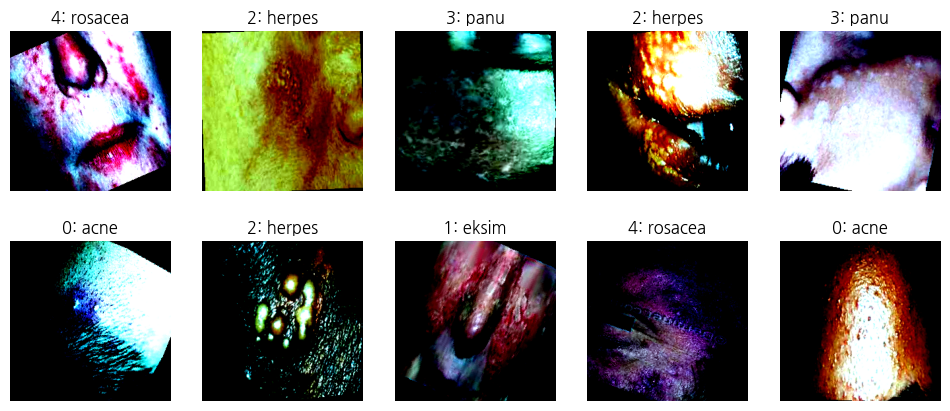

In [16]:
# 증강된 데이터셋 확인
train_dataset = ourDataset(base_dir=train_dir, transform = transform['train'])

train_indices = np.arange(len(train_dataset))
train_labels  = np.array(train_dataset.labels)

# undersampling
undersampled_train_indices = undersample_indices_from_labels(train_indices,train_labels)
undersampled_dataset = Subset(train_dataset, undersampled_train_indices)

train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# attribute 추가
base = undersampled_dataset.dataset if isinstance(undersampled_dataset, Subset) else undersampled_dataset
print(base.idx_to_cls)


iter_dataloader = iter(train_dataloader)

# 이미지 시각화
plt.figure(figsize=(12, 5))
for i, (augmented_image, label) in zip(range(10), iter_dataloader):
    plt.subplot(2, 5, i + 1)
    label_idx = label.item()
    plt.title(f"{label_idx}: {base.idx_to_cls[label_idx]}")
    plt.imshow(augmented_image[0].permute(1, 2, 0))
    plt.axis('off')
plt.show()

In [17]:
# 학습 데이터셋과 검증 데이터셋 나누기.
# 클래스별 고른 분포를 위해 sklearn의 split을 사용함 : pytorch의 random split은 고른 분포를 고려하지 않음

def stratified_split_indices(indices, labels, val_split_ratio=0.2, random_seed=42):
    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_split_ratio,
        stratify=labels,
        random_state=random_seed
    )
    return np.asarray(train_idx), np.asarray(val_idx)



# 데이터셋 스플릿
train_idx, val_idx = stratified_split_indices(
    undersampled_indices,
    all_labels[undersampled_indices],
    val_split_ratio=0.2,
    random_seed=42
)

test_dataset = ourDataset(test_dir, transform=transform["val"])
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 갯수 및 분포 확인
train_subset = Subset(base_dataset, train_idx)
val_subset   = Subset(base_dataset, val_idx)

train_dataset = WithTransform(train_subset, transform["train"])
val_dataset   = WithTransform(val_subset,   transform["val"])

print('학습 데이터', len(train_dataset))
print_cls_dist(train_subset)
print()
print('검증 데이터', len(val_dataset))
print_cls_dist(val_subset)
print()
print('테스트 데이터', len(test_dataset))

학습 데이터 1188
0.acne              : 237
1.eksim             : 238
2.herpes            : 238
3.panu              : 237
4.rosacea           : 238

검증 데이터 297
0.acne              : 60
1.eksim             : 59
2.herpes            : 59
3.panu              : 60
4.rosacea           : 59

테스트 데이터 50


In [74]:
# GPU / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 ( pretrained 모델 사용 )
#model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')  # EfficientNet_V2_s
#model.classifier[1] = nn.Linear(1280, num_classes)   # output의 크기를 맞춰줌
model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [75]:
model.classifier[-1]

Linear(in_features=768, out_features=1000, bias=True)

In [76]:
# 전체 얼리기
for param in model.parameters():
    param.requires_grad = False

# 마지막 부분 unfreeze
#for param in model.layer3.parameters():
#    param.requires_grad = True

for param in model.features[5:].parameters():
    param.requires_grad = True

In [77]:
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

# 모델을 GPU로 이동
model = model.to(device)

# 손실 함수와 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=4e-4, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0005, amsgrad=False)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.9)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=3)

# 에폭
n_epochs = 20

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(device)

cuda


In [78]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    ep = 0
    loop = tqdm(loader, desc="Training")
    
    for inputs, labels in loop:
    #for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        logits, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [79]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validating"):
        #for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [80]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    corrects = 0
    total = 0

    with torch.no_grad():
        for imgs, y in loader:
            imgs = imgs.to(device)
            y = y.to(device)

            logits = model(imgs)
            loss = criterion(logits, y)

            running_loss += loss.item() * y.size(0)
            pred = torch.argmax(logits, dim=1)
            corrects += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = running_loss / total
    acc = corrects / total * 100.0
    return avg_loss, acc

In [ ]:
from datetime import datetime

# 학습 시작
# 학습 결과를 저장할 리스트
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_test_acc = 0.0
current_lr = 4e-4

writer = SummaryWriter()

model.to(device)
for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")

    # learning rate 불러오기
    new_lr = scheduler.get_last_lr()[0]

    # 학습
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%", f"\tlr: {new_lr:.6f}" if current_lr != new_lr else "")

    # 검증
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Acc/train", train_acc, epoch)
    writer.add_scalar("Acc/val", val_acc, epoch)
    writer.add_scalar("LR", new_lr, epoch)

    # 결과 저장
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # 학습률 조정
    scheduler.step()

    current_lr = new_lr

    # 최고 모델 저장
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print()

writer.close()


Epoch 1/20


Training:  10%|█         | 1/10 [00:09<01:25,  9.53s/it, loss=1.68]

In [62]:
model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 5)

model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [63]:
def img_show(img, title):
    mean = torch.tensor(mean)
    std = torch.tensor(std)
    img_perm = img.permute(1,2,0)
    img_orig = img_perm * std + mean              # 역정규화로 이미지 복원
    plt.title(title)
    plt.imshow(img_orig)
    plt.show()


In [64]:
test_dir = "./data/skin_diseases/test/"

model.to(device)
model.eval()


test_dataset = ourDataset(test_dir, transform=transform["val"])
test_loader = DataLoader(test_dataset, batch_size=1)

corrects = 0

with torch.no_grad():
    for imgs, y in test_loader:
        imgs, y = imgs.to(device), y.to(device)
        preds = model(imgs)    
        pred = torch.max(preds,1)[1]
        corrects += (pred==y.to(device)).sum()
        
        #print(y)
        #img_grid = torchvision.utils.make_grid(imgs)
        #img_show(img_grid.cpu(), title=pred)
    
    acc = corrects / len(test_dataset) * 100

    print(f"Acc: {acc}")
    print(f"Corrects: {corrects} / {len(test_dataset)}")

Acc: 68.0
Corrects: 34 / 50
